In [7]:
import pandas as pd 
df = pd.read_csv("/home/manassecodev/dev/data-science-beginner/dataframes/data.csv")

In [8]:
df["price_paid"].describe()

count      1000
unique      528
top       $3.73
freq          8
Name: price_paid, dtype: object

In [9]:
df.price_paid = df.price_paid.apply(lambda x: x.replace("$", ""))
df.price_paid = df.price_paid.astype(float)

In [11]:
df["price_paid"].mean()

np.float64(6.461930000000001)

In [12]:
df["price_paid"].min()

np.float64(3.0)

In [13]:
df["price_paid"].max()

np.float64(10.0)

In [15]:
df["country"].unique().tolist()

['Canada', 'United States', 'Morocco', 'France', nan]

In [16]:
df["country"].value_counts()

country
France           408
United States    333
Canada           161
Morocco           54
Name: count, dtype: int64

In [18]:
df["gender"].value_counts(normalize=True)

gender
Female    0.529538
Male      0.470462
Name: proportion, dtype: float64

In [22]:
df.groupby("country").mean(numeric_only= True)

,id,price_paid,tax
country,,,
Canada,437.049689,6.319565,20.0
France,525.588235,6.420613,20.0
Morocco,492.425926,6.721667,20.0
United States,504.954955,6.557568,20.0


In [21]:
df.groupby("gender")["price_paid"].sum()

gender
Female    3165.26
Male      2833.61
Name: price_paid, dtype: float64

In [25]:
resultat = (
    df.groupby(["gender", "country"])["price_paid"]
      .mean()
      .reset_index()
      .rename(columns={"price_paid": "Prix moyen"})
)

resultat["Prix moyen"] = resultat["Prix moyen"].round(2)

display(resultat.style
        .set_caption("Prix moyen par genre et par pays")
        .format({"Prix moyen": "{:,.2f}"}))

,gender,country,Prix moyen
0,Female,Canada,6.42
1,Female,France,6.35
2,Female,Morocco,7.02
3,Female,United States,6.44
4,Male,Canada,6.12
5,Male,France,6.50
6,Male,Morocco,6.15
7,Male,United States,6.67


<Axes: xlabel='date'>

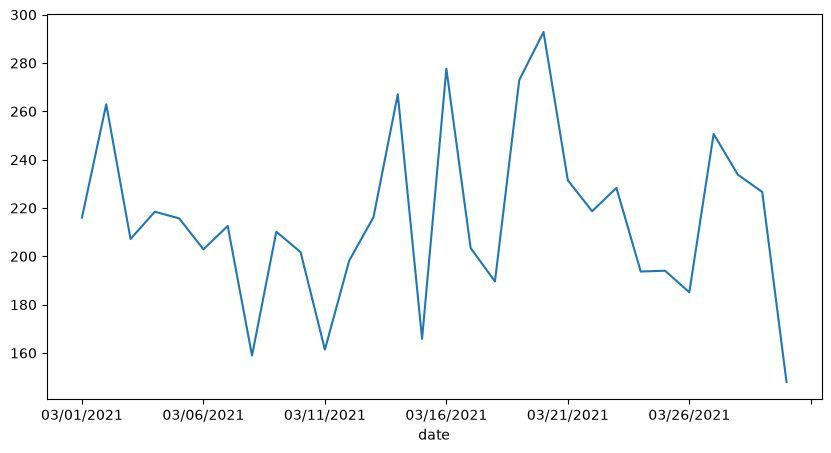

In [31]:
df.groupby("date")["price_paid"].sum().plot(figsize=[10,5])

<Axes: >

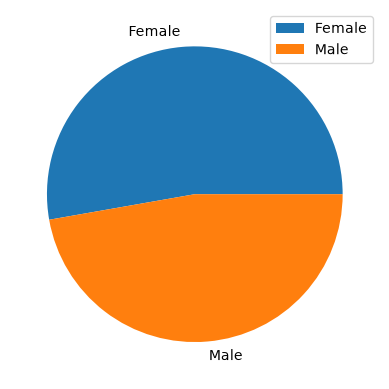

In [33]:
df.groupby("gender")["price_paid"].sum().plot.pie(legend = True)

<Axes: xlabel='country'>

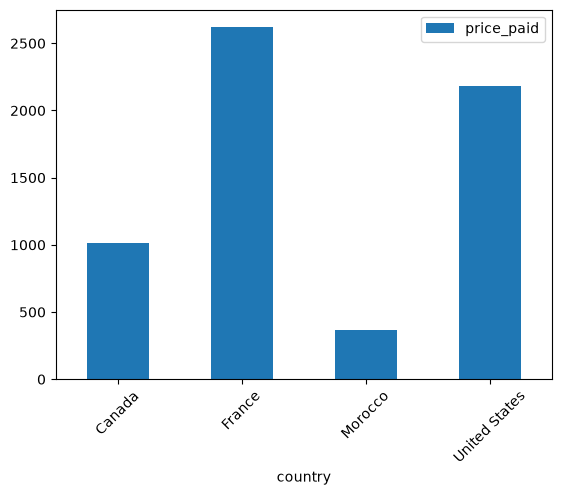

In [34]:
df.groupby("country")["price_paid"].sum().plot.bar(rot=45, legend= True)